# Mass Balance — Dry Control Cell (south of the SE delta block)

Water budget for the single mascon block immediately **south of the SE delta
block**, deep in the Kalahari.  It is the null / control case: with no river
inflow and (ideally) no lateral exchange,

$$P - ET \approx \Delta S ,$$

so the residual $P - ET - \Delta S$ should be ~0 with no seasonal signature.
(This notebook supersedes `mass_balance_grace_dry_pixel.ipynb`, which analysed
the identical block.)  Pipeline: `src/` modules.

## 1 — Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import IFrame, display

from src.gee_utils import ee_init
from src.grace_blocks import (discover_blocks, describe, neighbour_block, block_area_m2,
                              blocks_union, gdf_union, block_tws, domain_tws, tws_difference,
                              ee_geometry, block_map)
from src.et_products import compute_et_products, et_wide, summarize
from src.precip import compute_chirps
from src.discharge import load_mohembo_monthly
from src.balance import assemble_balance, monthly_climatology, write_outputs
from src.lateral_flux import per_model_fits, summarize_fits
from src import balance_plots as bp

# ── Paths ──
DELTA_SHP = Path("../data/regions/Delta_UCB_WGS84/Delta_UCB_WGS84.shp")
GRACE_NC  = Path("../data/grace_subsaharan_out/"
                 "GRCTellus.JPL.200204_202507.GLO.RL06.3M.MSCNv04CRI.nc")

assert DELTA_SHP.exists() and GRACE_NC.exists()

# ── Time window ──
START = "2002-04-01"                      # GRACE begins April 2002
END = pd.Timestamp.today().normalize().replace(day=1).strftime("%Y-%m-%d")   # last complete month

# ── Output ──
GEOM_TAG = "grace_dry_control"
FIG_DIR = Path("../figures/ET comparison") / GEOM_TAG
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Earth Engine products: False = use the CSVs cached in FIG_DIR (computed if
#    missing); True = force a recompute (~20 min) ──
RUN_EE = False

print(f"Window : {START} → {END}")
print(f"Figures: {FIG_DIR.resolve()}")

Window : 2002-04-01 → 2026-10-01
Figures: /Users/octaviacrompton/Projects/Okavango-water-balance/figures/ET comparison/grace_dry_control


In [2]:
gdf = gpd.read_file(DELTA_SHP).to_crs(epsg=4326)
delta_union = gdf_union(gdf)          # geopandas-version-safe union_all
centroid = delta_union.centroid
print(f"Delta bounds: {delta_union.bounds}")

Delta bounds: (21.79128644270243, -20.185785441436625, 24.033221169007163, -18.26936168824883)


## 2 — Discover GRACE mascon blocks & select the dry control cell

In [3]:
blocks = discover_blocks(GRACE_NC, ref_geom=delta_union, pad_deg=8.0)
delta_blocks = [b for b in blocks if b["intersects_ref"]]
print(f"Total mascon blocks discovered: {len(blocks)}")
print("Blocks intersecting the delta polygon:")
for b in delta_blocks:
    print(f"  {describe(b)}  frac_delta={b['frac_ref']:.1%}")

Total mascon blocks discovered: 42
Blocks intersecting the delta polygon:
  B017 (NW)  lon 19.00–22.00  lat -19.50–-16.50  36 px  frac_delta=1.6%
  B018 (NE)  lon 22.00–25.50  lat -19.50–-16.50  42 px  frac_delta=60.7%
  B024 (SW)  lon 19.50–22.50  lat -22.50–-19.50  36 px  frac_delta=4.7%
  B025 (SE)  lon 22.50–25.50  lat -22.50–-19.50  36 px  frac_delta=33.0%


In [4]:
SE_BLOCK = [b for b in delta_blocks if b["quadrant"] == "SE"][0]
NE_BLOCK = [b for b in delta_blocks if b["quadrant"] == "NE"][0]
DRY_BLOCK = neighbour_block(SE_BLOCK, blocks, "S")
SOUTH_BLOCK = neighbour_block(DRY_BLOCK, blocks, "S")
USE_BLOCKS = [DRY_BLOCK]
DOMAIN_LABEL = "Dry control cell"
print("SE (delta)  :", describe(SE_BLOCK))
print("Dry control :", describe(DRY_BLOCK), f" intersects delta: {DRY_BLOCK['intersects_ref']}")
print("South       :", describe(SOUTH_BLOCK) if SOUTH_BLOCK else None)
m = block_map(blocks, {"#d62728": USE_BLOCKS, "#1b9e77": [SE_BLOCK], "#d95f02": [SOUTH_BLOCK]}, ref_gdf=gdf,
              center=(centroid.y - 2, centroid.x), zoom_start=6, ref_name="Delta polygon")
map_path = FIG_DIR / "study_area_map_dry_control.html"; m.save(str(map_path))
IFrame(src=str(map_path), width=800, height=500)

SE (delta)  : B025 (SE)  lon 22.50–25.50  lat -22.50–-19.50  36 px
Dry control : B033 (SE)  lon 23.00–26.50  lat -25.50–-22.50  42 px  intersects delta: False
South       : B040 (SE)  lon 24.00–27.00  lat -28.00–-25.50  30 px


## 3 — Earth Engine geometry + area

In [5]:
ee_init()
block_geom = ee_geometry(USE_BLOCKS)          # one polygon per block
block_union = blocks_union(USE_BLOCKS)        # shapely, for GLEAM
block_area_m2_ = sum(block_area_m2(b) for b in USE_BLOCKS)
ee_area = float(block_geom.area(maxError=1).getInfo())
print(f"Domain area: {block_area_m2_/1e6:,.0f} km² (geodesic)   EE: {ee_area/1e6:,.0f} km²")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Domain area: 118,339 km² (geodesic)   EE: 118,607 km²


## 4 — Monthly ET over the dry control block

Loaded cached: ../figures/ET comparison/grace_dry_control/et_monthly.csv  (2133 rows)


,first,last,n,mean_mm,coverage
dataset,,,,,
ERA5Land_totalET,2002-04-01,2026-08-01,293,33.6,1.0
FLDAS_Evap,2002-04-01,2026-08-01,293,32.6,1.0
GLEAM_v42a,2002-04-01,2024-12-01,273,33.8,1.0
MOD16A2GF_v61,2002-04-01,2025-12-01,285,16.7,1.0
PML_v2_landET,2002-04-01,2024-12-01,273,46.3,1.0
TerraClimate_aet,2002-04-01,2024-12-01,273,26.6,1.0
USGS_SSEBop,2003-01-01,2022-05-01,233,58.7,1.0
WaPORv3_AETI,2018-01-01,2026-08-01,104,46.1,1.0


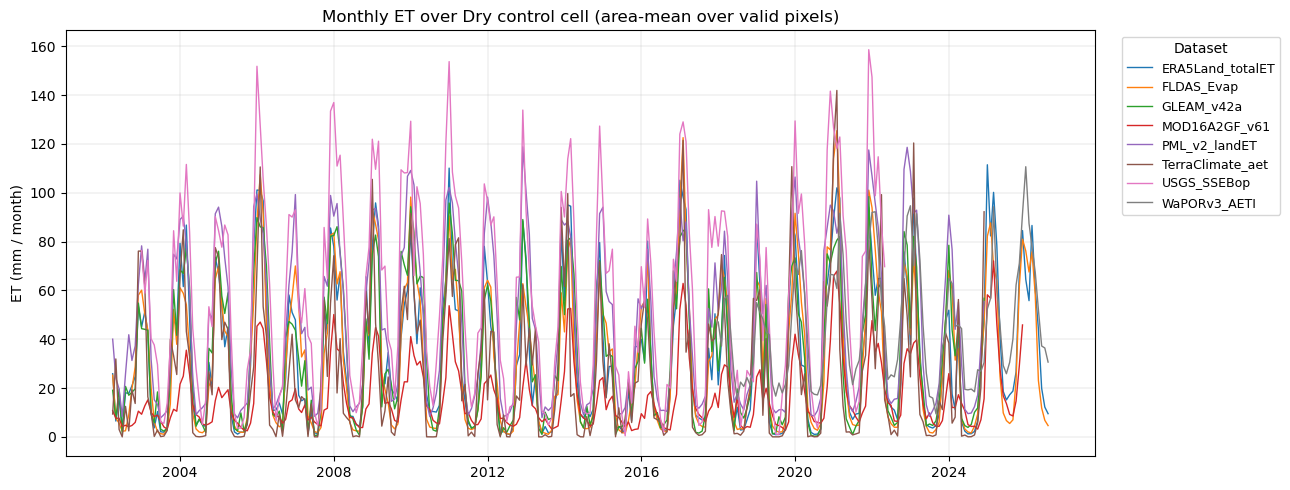

In [6]:
df_et = compute_et_products(block_geom, block_area_m2_, START, END,
                            csv_path=FIG_DIR / "et_monthly.csv", run=RUN_EE,
                            gleam_geom=block_union)
display(summarize(df_et))
et_mm_wide = et_wide(df_et, "et_mm_mean")
bp.plot_et_products(et_mm_wide, f"Monthly ET over {DOMAIN_LABEL} (area-mean over valid pixels)",
                    save=FIG_DIR / "et_products.png")
plt.show()

## ET diagnostic — delta polygon vs GRACE domain

The same products over the **delta polygon**, for comparison with the mascon
domain.  Large differences mean the products respond to wetland conditions.

Loaded cached: ../figures/ET comparison/grace_dry_control/et_monthly_delta_poly.csv  (2133 rows)


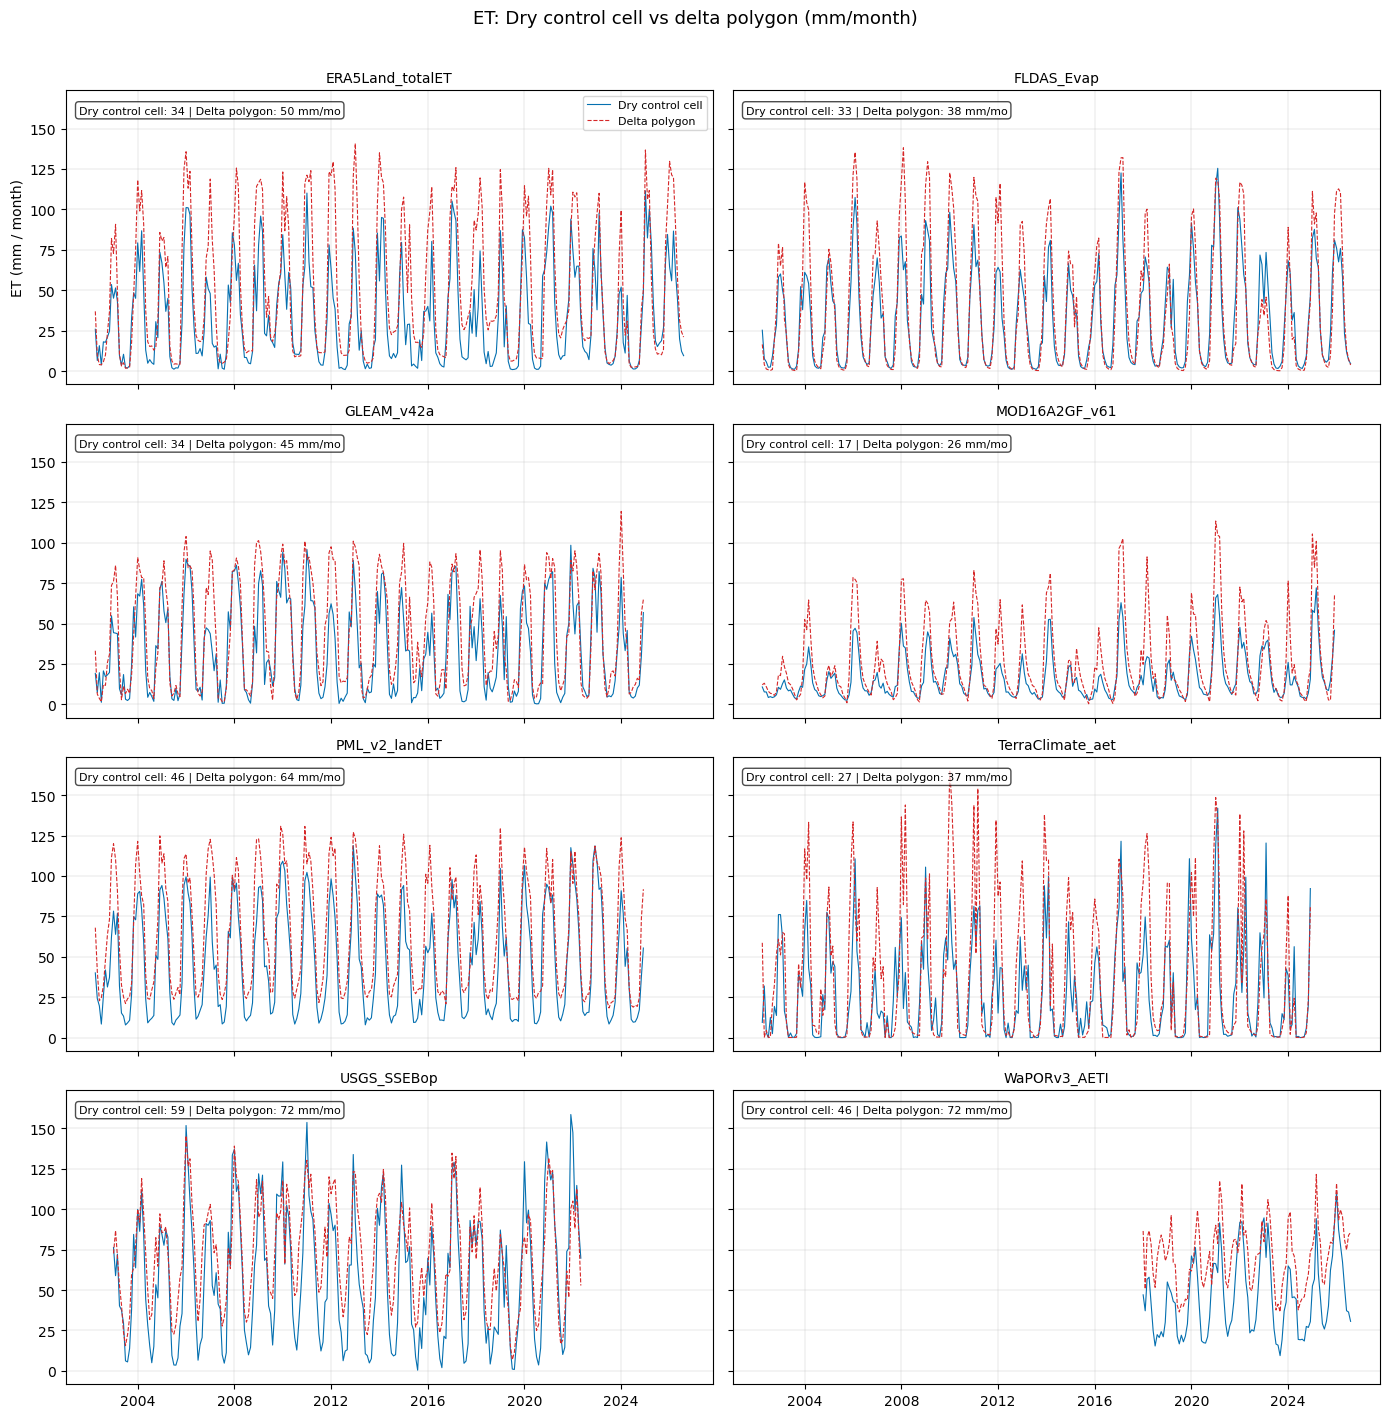

In [7]:
delta_geom_ee = ee_geometry(delta_union)
delta_area_m2 = block_area_m2(delta_union)
df_et_delta = compute_et_products(delta_geom_ee, delta_area_m2, START, END,
                                  csv_path=FIG_DIR / "et_monthly_delta_poly.csv", run=RUN_EE,
                                  gleam_geom=delta_union)
bp.plot_et_two_domains(et_mm_wide, et_wide(df_et_delta, "et_mm_mean"), DOMAIN_LABEL, "Delta polygon",
                       f"ET: {DOMAIN_LABEL} vs delta polygon (mm/month)",
                       save=FIG_DIR / "et_delta_vs_grace_domain.png")
plt.show()

## 5 — CHIRPS precipitation

In [8]:
df_chirps = compute_chirps(block_geom, block_area_m2_, START, END,
                           csv_path=FIG_DIR / "chirps_monthly.csv", run=RUN_EE)

Loaded cached: ../figures/ET comparison/grace_dry_control/chirps_monthly.csv  (294 rows)


## GRACE TWS over the domain

Block TWS comes from the **local JPL netCDF** (all pixels in a mascon share one
series), labelled by the midpoint of each solution's `time_bounds`.  The earlier
Earth Engine reduction labelled solutions by the day before their period and
put ~90 % of months one month early.

GRACE solutions: 246  (2002-04-01 → 2025-07-01)


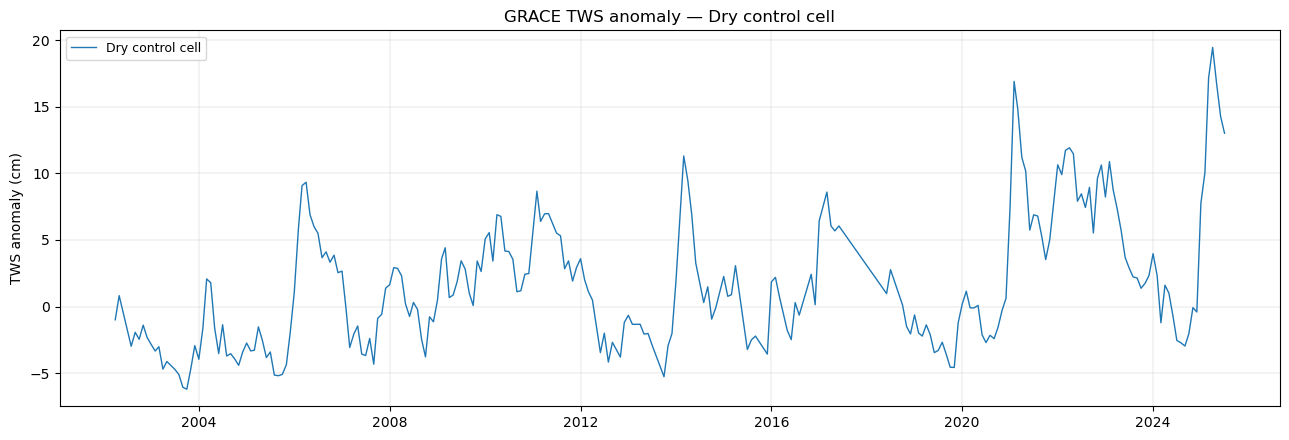

In [9]:
df_tws = domain_tws(GRACE_NC, USE_BLOCKS)
df_tws.to_csv(FIG_DIR / "grace_monthly.csv")
print(f"GRACE solutions: {len(df_tws)}  ({df_tws.index.min().date()} → {df_tws.index.max().date()})")
bp.plot_tws_series({DOMAIN_LABEL: df_tws["TWS_cm"]}, f"GRACE TWS anomaly — {DOMAIN_LABEL}")
plt.show()

### Adjacent-block TWS differences (subsurface-flow proxies)

North (SE delta) − Dry control: mean -1.98 cm, std 2.85 cm


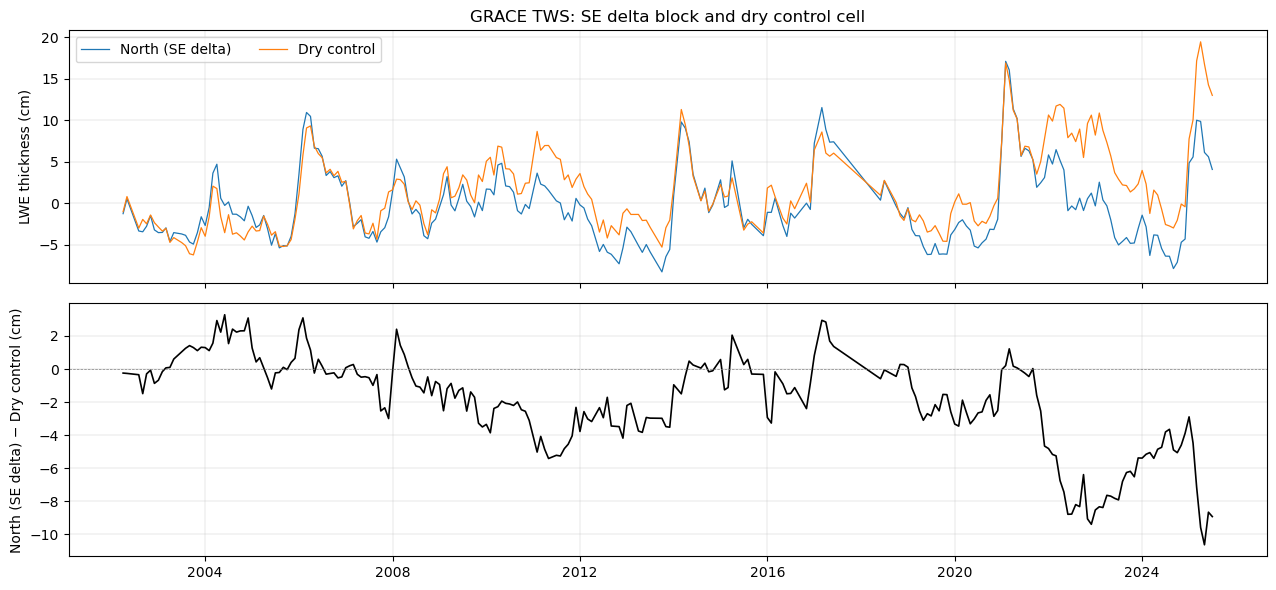

Dry control − South: mean -0.31 cm, std 2.95 cm


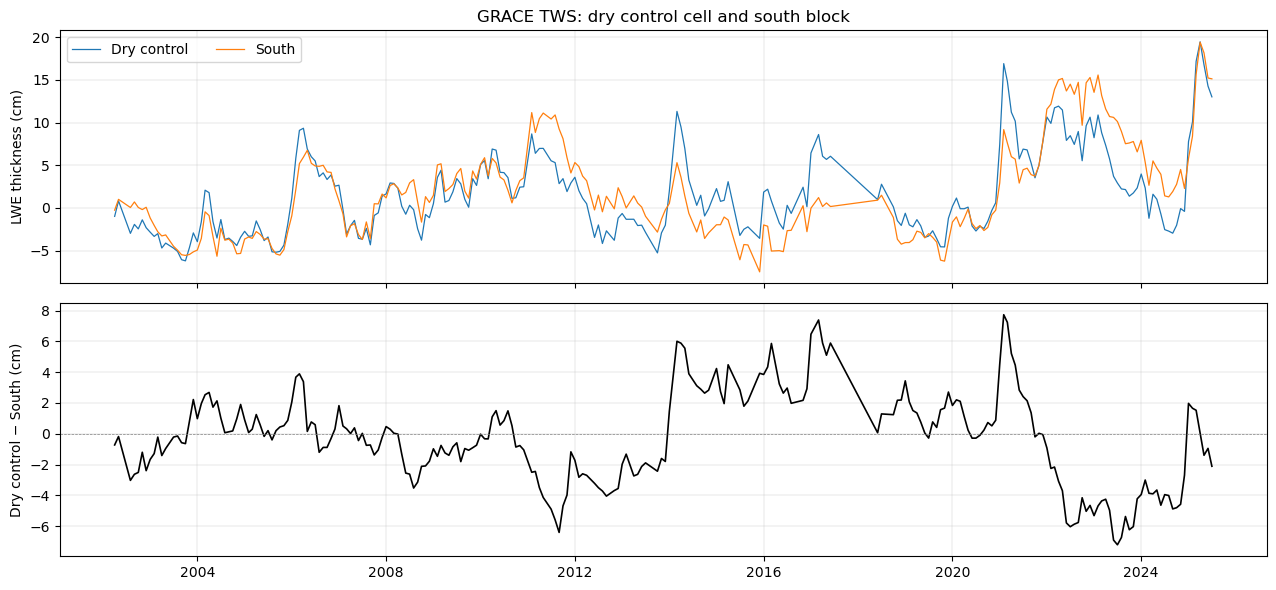

In [10]:
df_n_dc = tws_difference(GRACE_NC, SE_BLOCK, DRY_BLOCK, "N_DC_diff_cm")
df_dc_s = tws_difference(GRACE_NC, DRY_BLOCK, SOUTH_BLOCK, "DC_S_diff_cm")
bp.plot_tws_pair(df_n_dc, df_n_dc.columns[0], df_n_dc.columns[1], "N_DC_diff_cm", "North (SE delta)", "Dry control",
                 "GRACE TWS: SE delta block and dry control cell"); plt.show()
bp.plot_tws_pair(df_dc_s, df_dc_s.columns[0], df_dc_s.columns[1], "DC_S_diff_cm", "Dry control", "South",
                 "GRACE TWS: dry control cell and south block"); plt.show()

## Mass-balance assembly

All terms are placed on a continuous month-start grid.  ΔS uses a **centred
difference** `(S[t+1] − S[t−1]) / 2`, because a GRACE solution is the mean state
of its month while P, ET and Q are month totals.  A single missing GRACE month is
linearly interpolated before differencing (`fill_tws_gap_months=1`); longer
gaps, including the 11-month GRACE/GRACE-FO gap, are never bridged.  In the
ΔS panel, hollow markers show months whose ΔS depends on an interpolated
month.  ET is the median of the available products each month, used only where
at least 4 products contribute (`min_et_products=4`); product coverage thins
from 7–8 products through 2024 to 4 in 2025 and 3 in 2026.

In [11]:
bal = assemble_balance(df_et, df_chirps, df_tws, block_area_m2_,
                       qin=None,
                       extra={"N_DC_diff_cm": df_n_dc["N_DC_diff_cm"], "DC_S_diff_cm": df_dc_s["DC_S_diff_cm"]},
                       start=START, ds_scheme="centered",
                       fill_tws_gap_months=1,       # interpolate single missing GRACE months
                       min_et_products=4)         # ET median needs ≥ 4 products
df_balance = bal.df
print(bal.summary())
print("\nResidual = P − ET − ΔS  (should be ≈ 0 for a closed cell)")
df_balance.tail(6)

Balance grid: 294 months (2002-04-01 → 2026-09-01), 241 with full closure
ΔS scheme: centered;  area = 118,339 km²
TWS gaps ≤ 1 month interpolated: 11 months (22 ΔS months depend on them)
ET median requires ≥ 4 products: 8 months with ET data dropped
Mean over closure months (mm/month):
  P         36.6
  ET        36.4
  ΔS         1.1
  resid     -0.8

Residual = P − ET − ΔS  (should be ≈ 0 for a closed cell)


,P_mm,P_km3,ET_mm,ET_km3,n_et_products,TWS_cm,TWS_km3,N_DC_diff_cm,DC_S_diff_cm,et_too_few_products,TWS_filled,dS_cm,dS_km3,dS_uses_filled_tws,dS_mm,resid_km3,resid_mm,has_closure
date,,,,,,,,,,,,,,,,,,
2026-04-01,69.567753,8.232556,NaN,NaN,3.0,NaN,NaN,NaN,NaN,True,False,NaN,NaN,False,NaN,NaN,NaN,False
2026-05-01,5.974333,0.706995,NaN,NaN,3.0,NaN,NaN,NaN,NaN,True,False,NaN,NaN,False,NaN,NaN,NaN,False
2026-06-01,6.807171,0.805552,NaN,NaN,3.0,NaN,NaN,NaN,NaN,True,False,NaN,NaN,False,NaN,NaN,NaN,False
2026-07-01,0.000000,0.000000,NaN,NaN,3.0,NaN,NaN,NaN,NaN,True,False,NaN,NaN,False,NaN,NaN,NaN,False
2026-08-01,2.083883,0.246604,NaN,NaN,3.0,NaN,NaN,NaN,NaN,True,False,NaN,NaN,False,NaN,NaN,NaN,False
2026-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,NaN,NaN,False,NaN,NaN,NaN,False


## 7 — Mass-balance plots

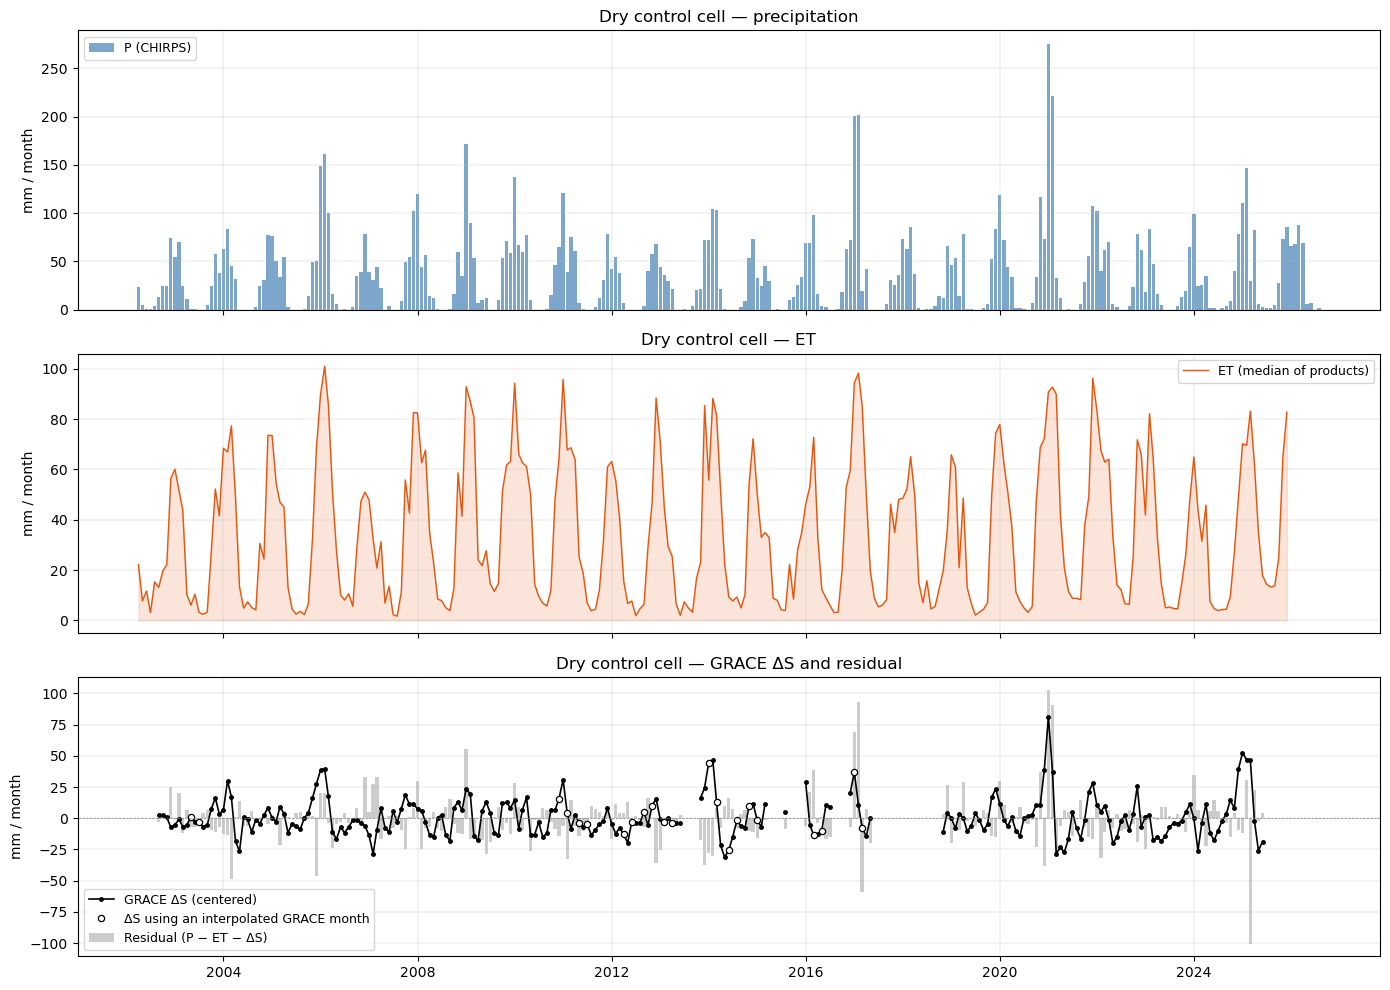

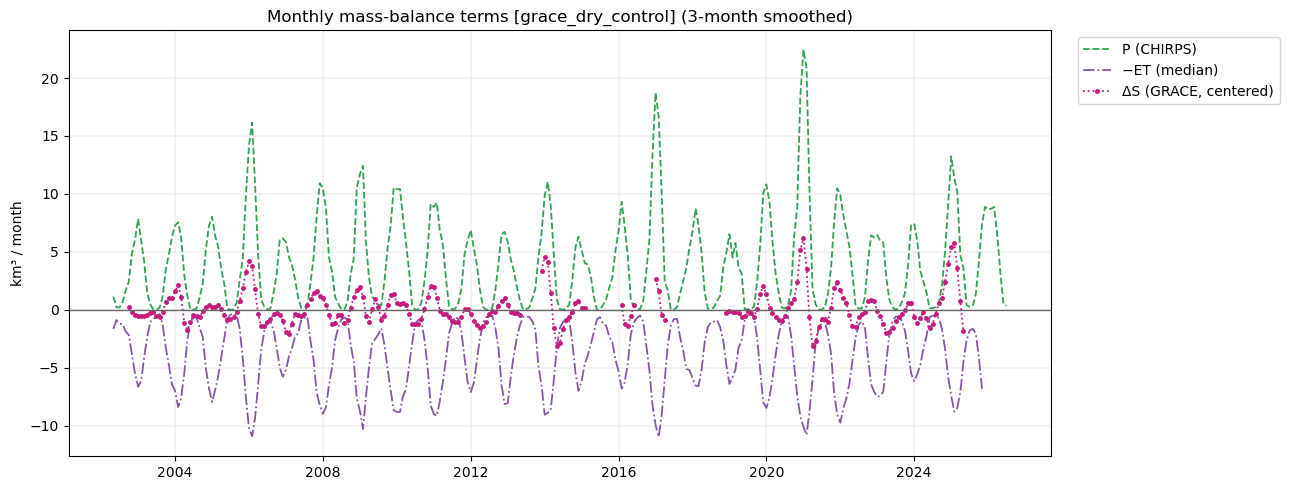

Cumulative residual over 241 closure months: -23.94 km³ (mean -0.099 km³/month)


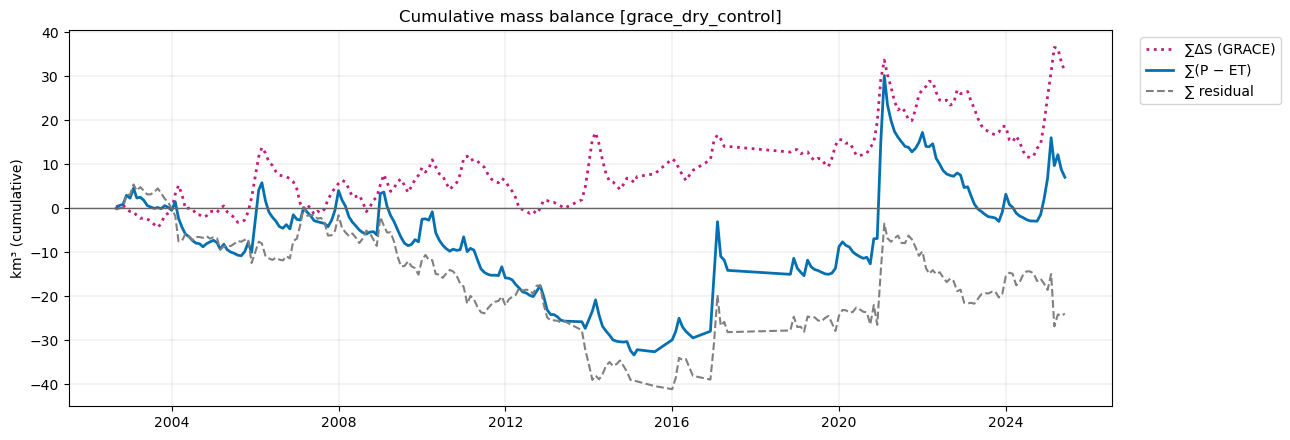

In [12]:
bp.plot_balance_panels(bal, DOMAIN_LABEL, save=FIG_DIR / "mass_balance_panels.png"); plt.show()
bp.plot_terms(bal, f"Monthly mass-balance terms [{GEOM_TAG}]", save=FIG_DIR / "mass_balance_terms.png"); plt.show()
bp.plot_cumulative(bal, f"Cumulative mass balance [{GEOM_TAG}]", save=FIG_DIR / "cumulative_sums.png"); plt.show()

## 7a — Per-ET-product diagnostics

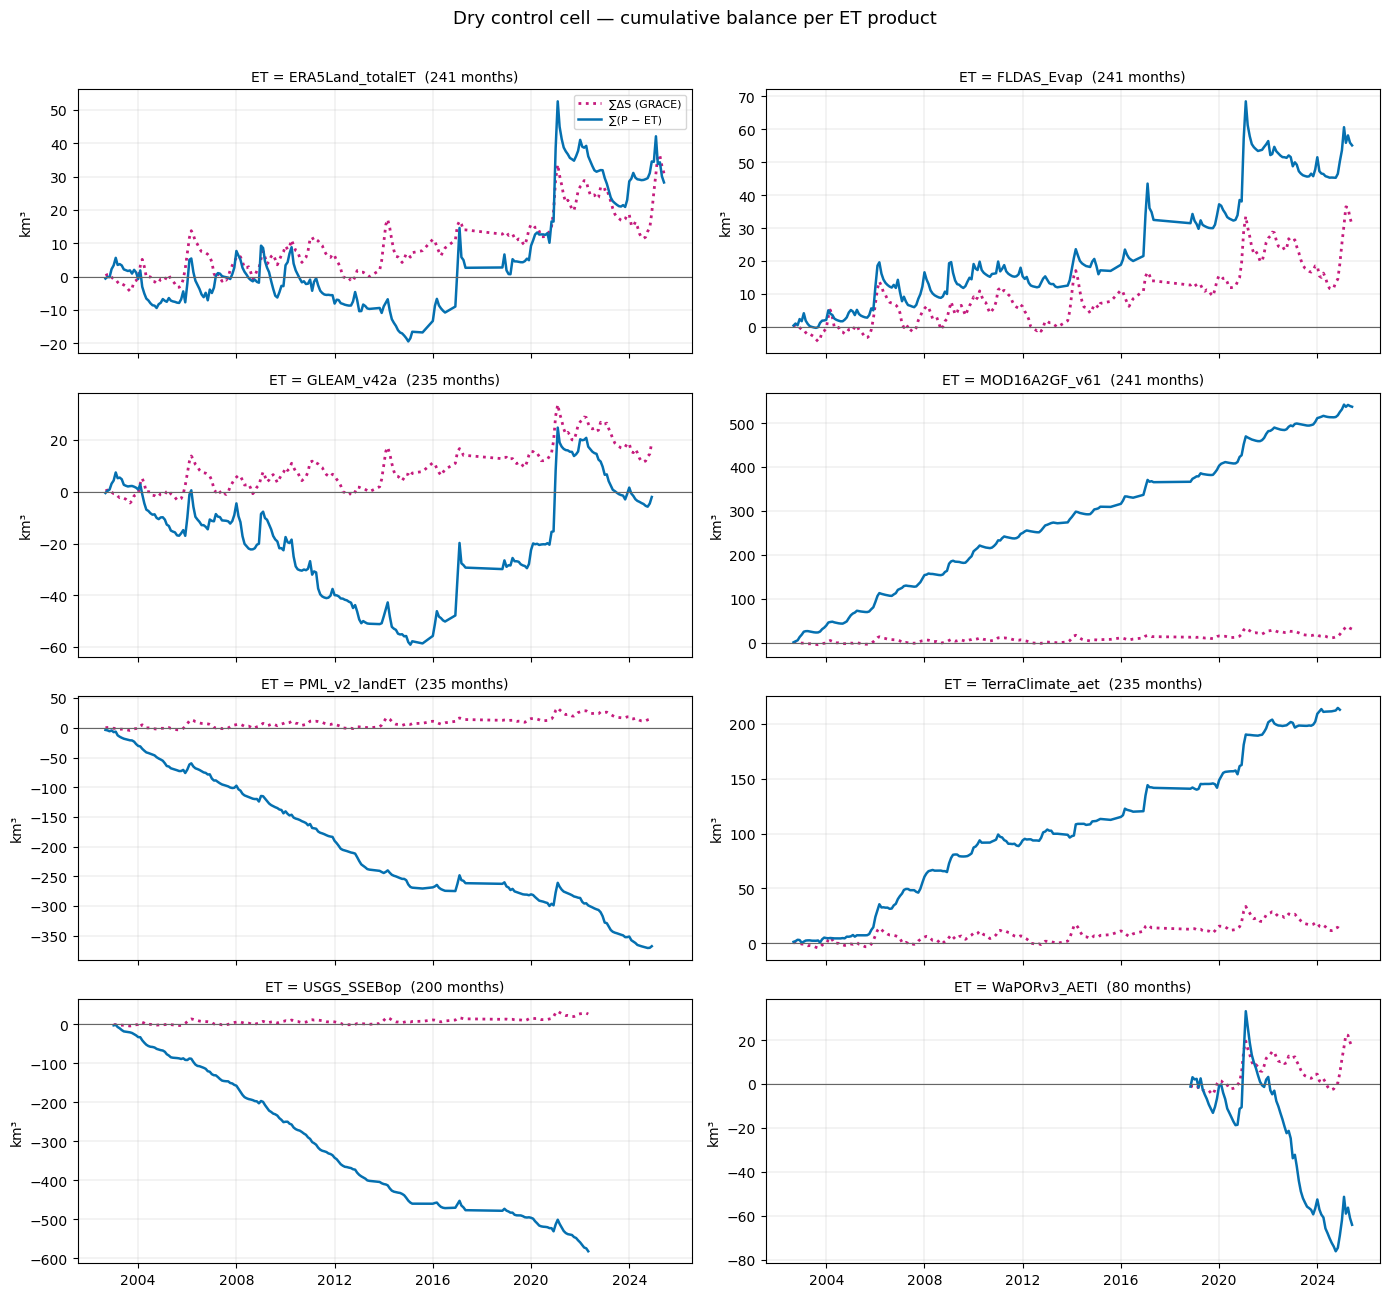

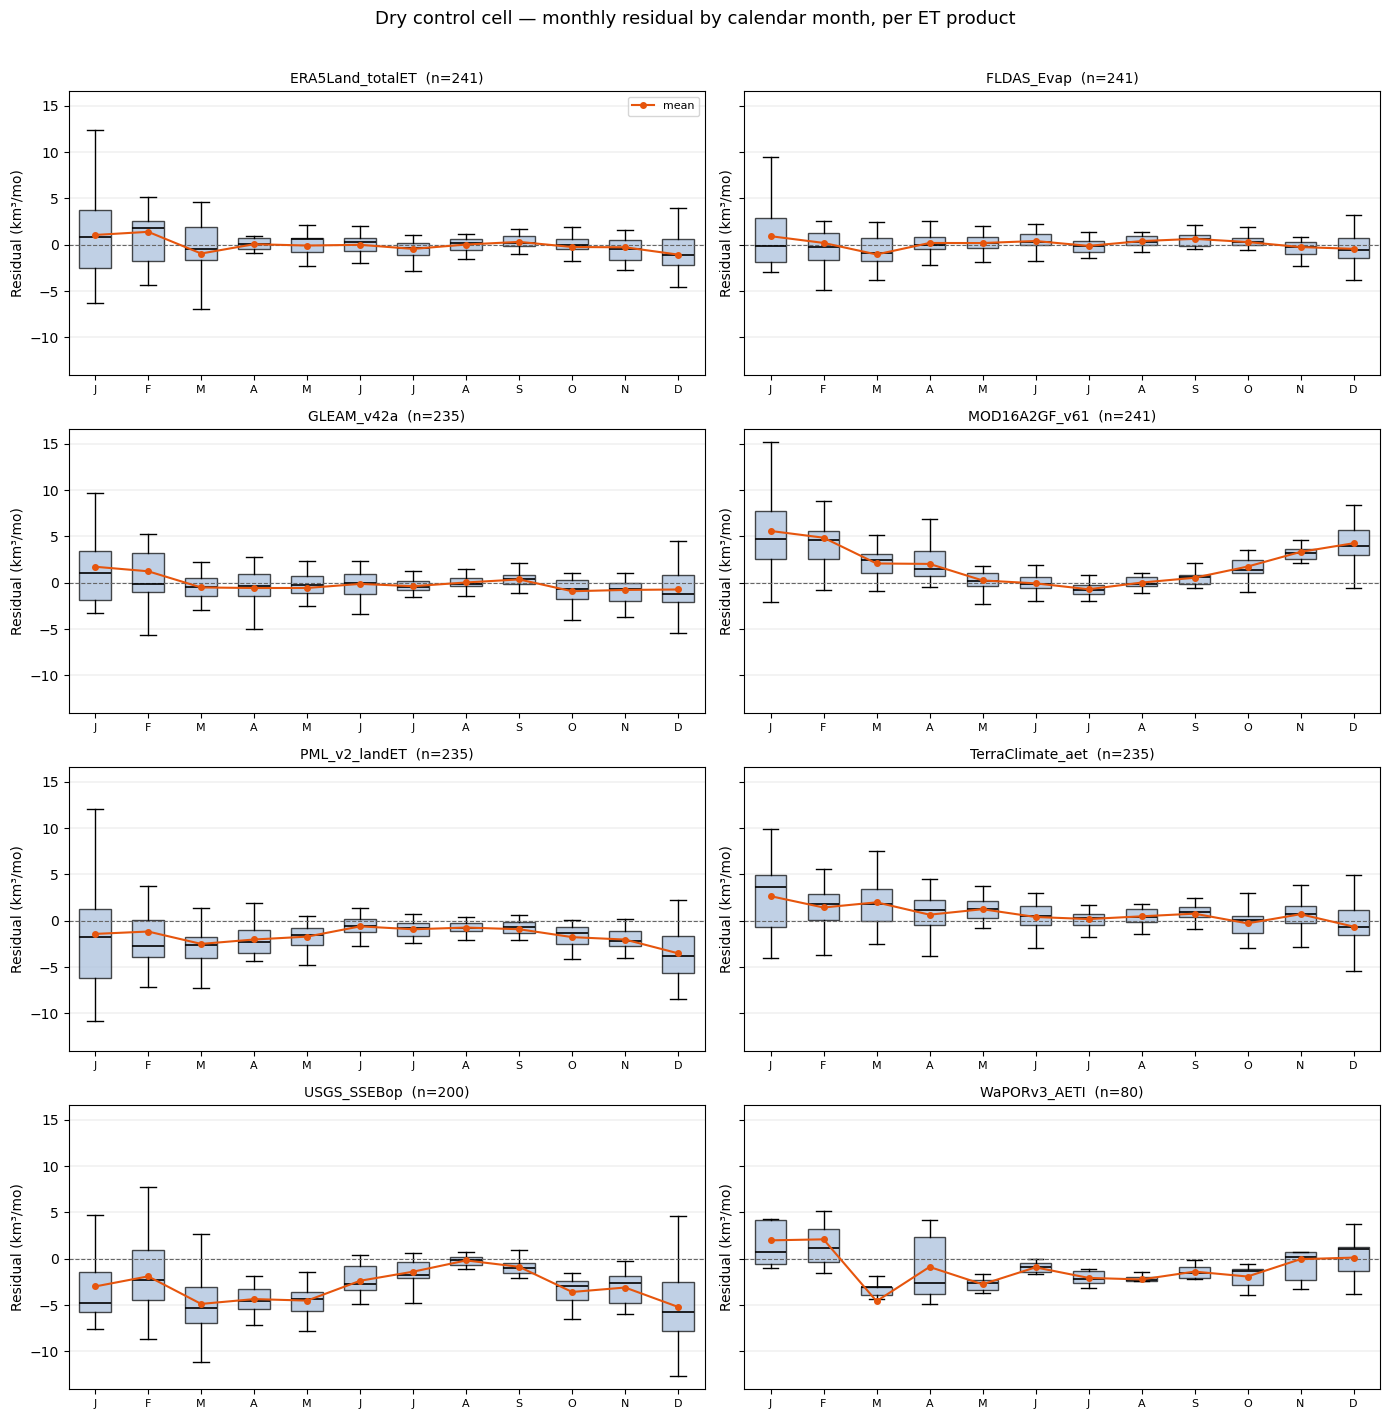

In [13]:
bp.plot_per_model_cumulative(bal, DOMAIN_LABEL, fig_dir=FIG_DIR); plt.show()
bp.plot_monthly_divergence(bal, f"{DOMAIN_LABEL} — monthly residual by calendar month, per ET product",
                           save=FIG_DIR / "monthly_divergence_by_model.png"); plt.show()

## Tunable lateral-flux terms

$$\text{flux}_t + \sum_k \alpha_k\,x_{k,t} + c \approx \Delta S_t$$

where $x_k$ are TWS head differences between adjacent mascon blocks (cm).  The
fit is on **monthly** residuals with an intercept $c$ that absorbs a constant
ET-product bias, and the reported improvement is relative to that bias-only
null.  (The earlier version regressed cumulative residuals on cumulative head
differences; since the head differences have a non-zero mean, that regressor
is nearly a straight line and α mostly fitted each product's drift.)  A real
lateral flux should give α of the **same sign for every ET product**.

── 1-parameter: α × (S_N − S_DC) ──
        ET_model  alpha_N_DC_diff_cm  intercept  RMSE_null_km3  RMSE_fit_km3  improvement_pct   n
      FLDAS_Evap             -0.0297    -0.1226         1.9560        1.9541           0.0948 230
TerraClimate_aet             -0.0844    -0.9839         2.4057        2.3945           0.4621 224
      GLEAM_v42a             -0.0494     0.0330         2.5238        2.5202           0.1437 224
ERA5Land_totalET             -0.0370    -0.0340         2.5624        2.5602           0.0856 230
   PML_v2_landET             -0.1310     1.4677         2.7824        2.7592           0.8335 224
     USGS_SSEBop             -0.1639     2.8533         3.0693        3.0506           0.6111 189
   MOD16A2GF_v61             -0.1027    -2.2639         3.1104        3.0964           0.4487 230
    WaPORv3_AETI             -0.3201    -0.3444         3.7987        3.6789           3.1533  80

Median RMSE improvement over bias-only null: 0.5%
  alpha_N_DC_diff_cm: median -0

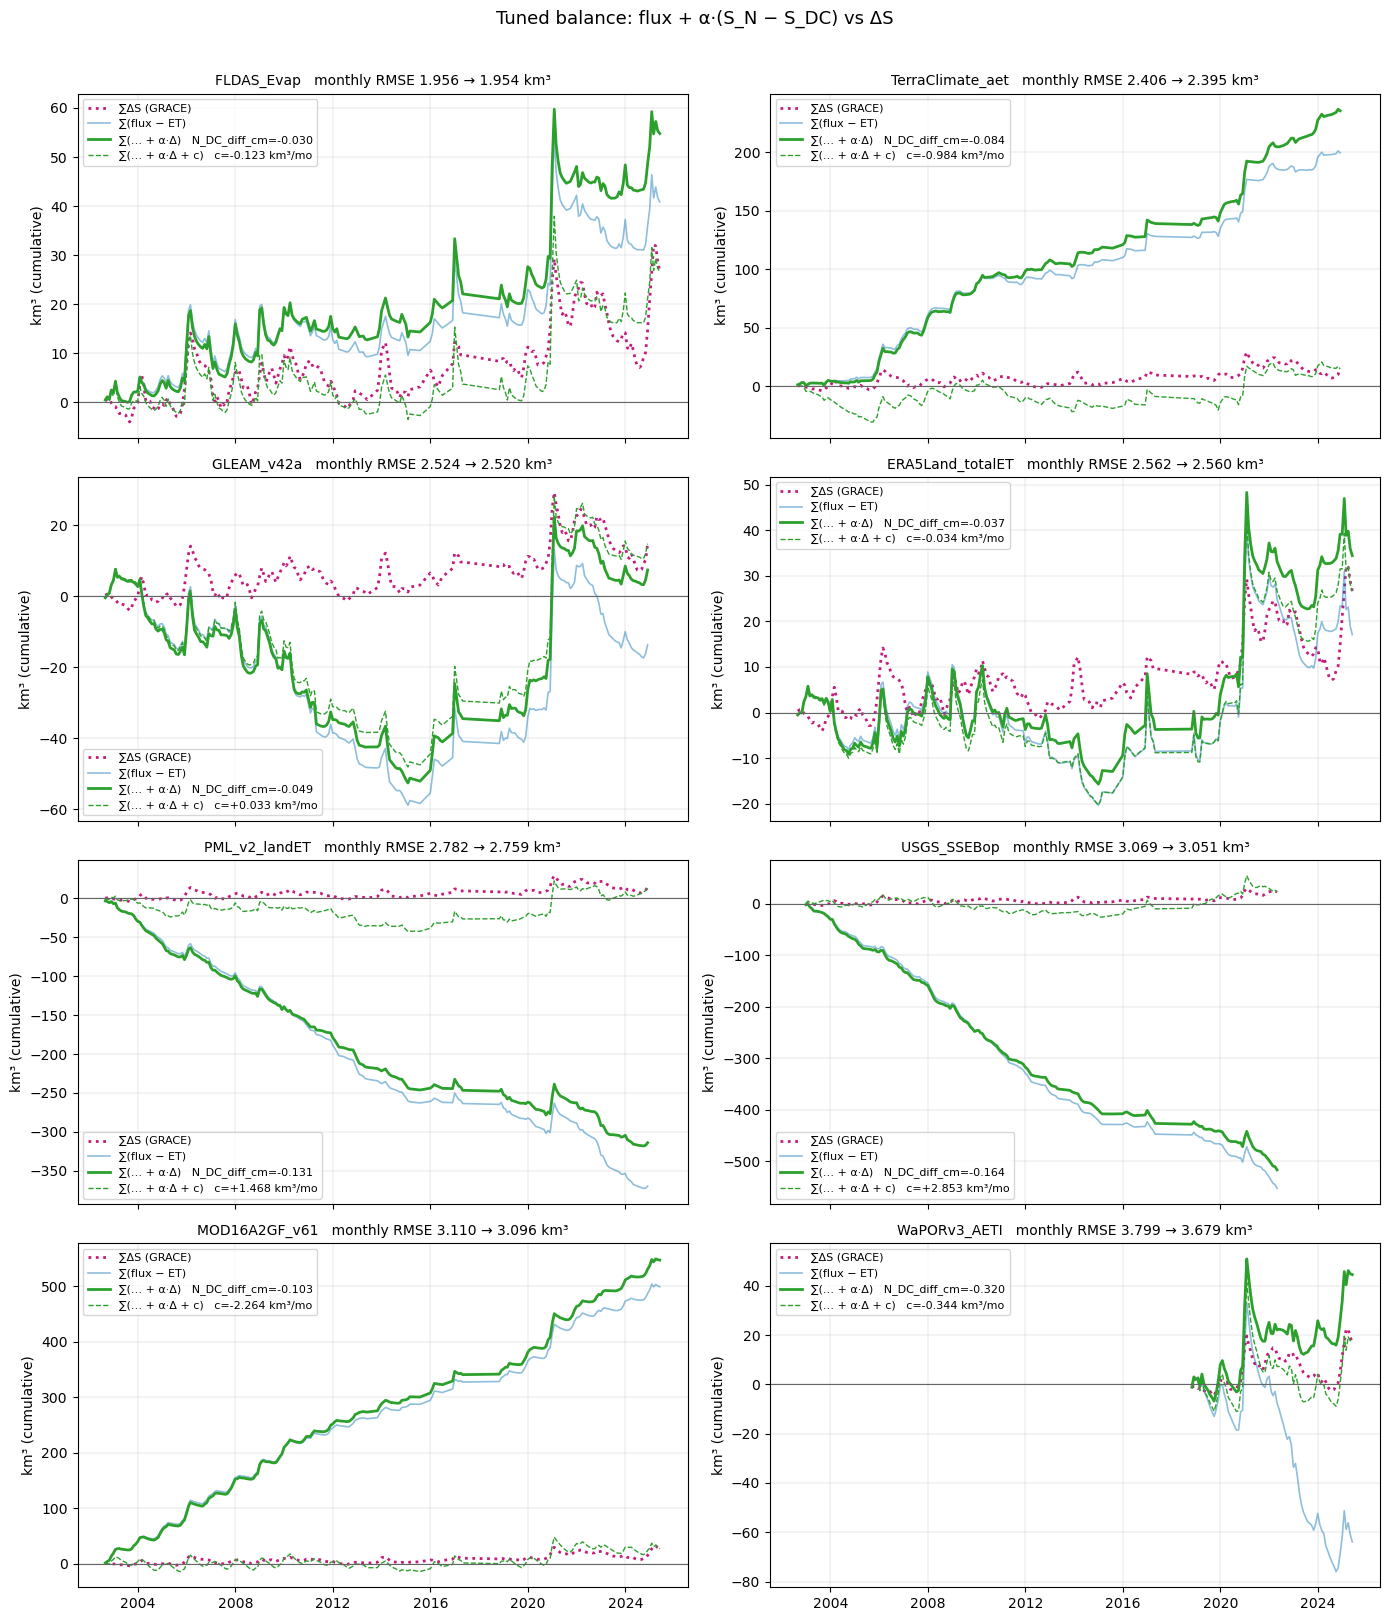

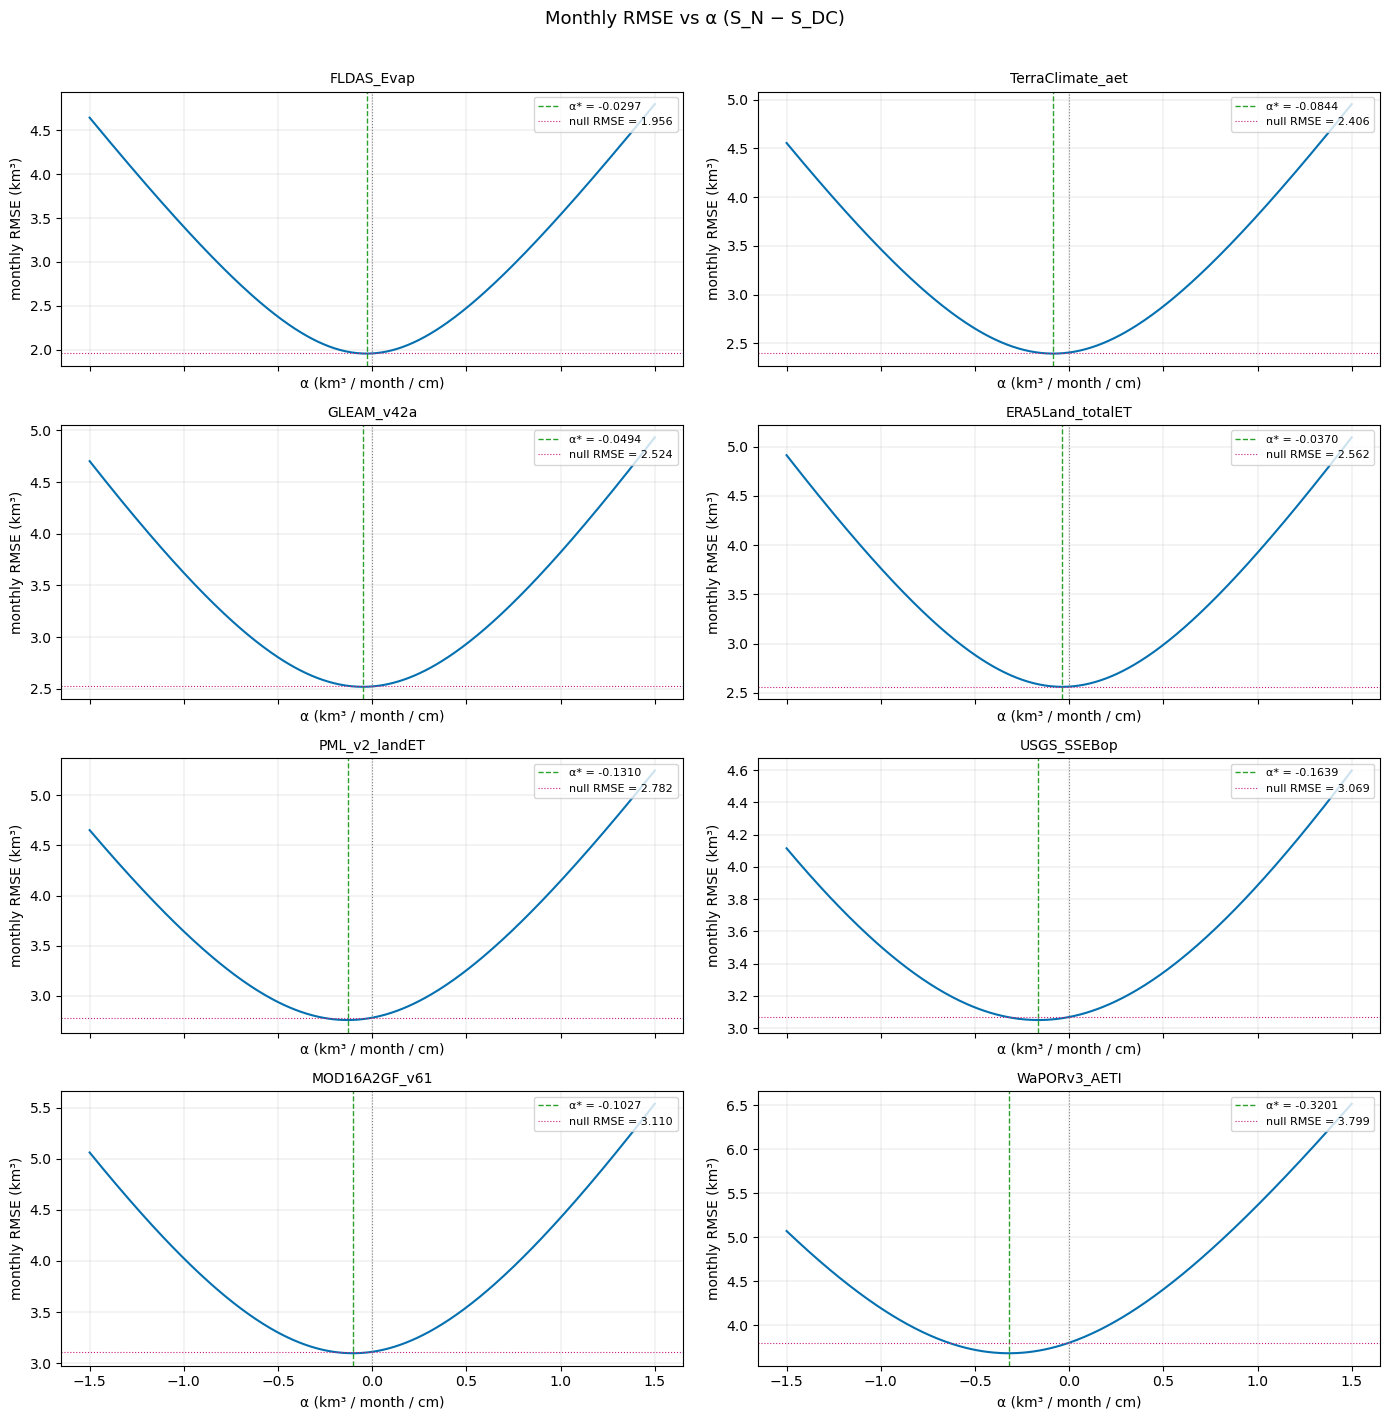

In [14]:
results_1p, plot_1p = per_model_fits(bal, ["N_DC_diff_cm"])
summarize_fits(results_1p, "1-parameter: α × (S_N − S_DC)")
bp.plot_tuned_cumulative(results_1p, plot_1p, f"Tuned balance: flux + α·(S_N − S_DC) vs ΔS",
                         save=FIG_DIR / "tuned_alpha_cumulative.png"); plt.show()
bp.plot_alpha_sensitivity(bal, results_1p, "N_DC_diff_cm", title=f"Monthly RMSE vs α (S_N − S_DC)",
                          save=FIG_DIR / "rmse_vs_alpha.png"); plt.show()

── 2-parameter: α × (S_N − S_DC) + β × (S_DC − S_S), β ≤ 0 ──
        ET_model  alpha_N_DC_diff_cm  alpha_DC_S_diff_cm  intercept  RMSE_null_km3  RMSE_fit_km3  improvement_pct   n
      FLDAS_Evap             -0.0259             -0.0054    -0.1170         1.9560        1.9541           0.0966 230
TerraClimate_aet              0.1207             -0.2580    -0.7049         2.4057        2.3366           2.8716 224
      GLEAM_v42a              0.1222             -0.2158     0.2664         2.5238        2.4818           1.6640 224
ERA5Land_totalET             -0.0355             -0.0021    -0.0318         2.5624        2.5602           0.0857 230
   PML_v2_landET             -0.0136             -0.1476     1.6274         2.7824        2.7429           1.4202 224
   MOD16A2GF_v61              0.0838             -0.2659    -1.9914         3.1104        3.0429           2.1708 230
     USGS_SSEBop             -0.1430             -0.0301     2.8879         3.0693        3.0499           0.632

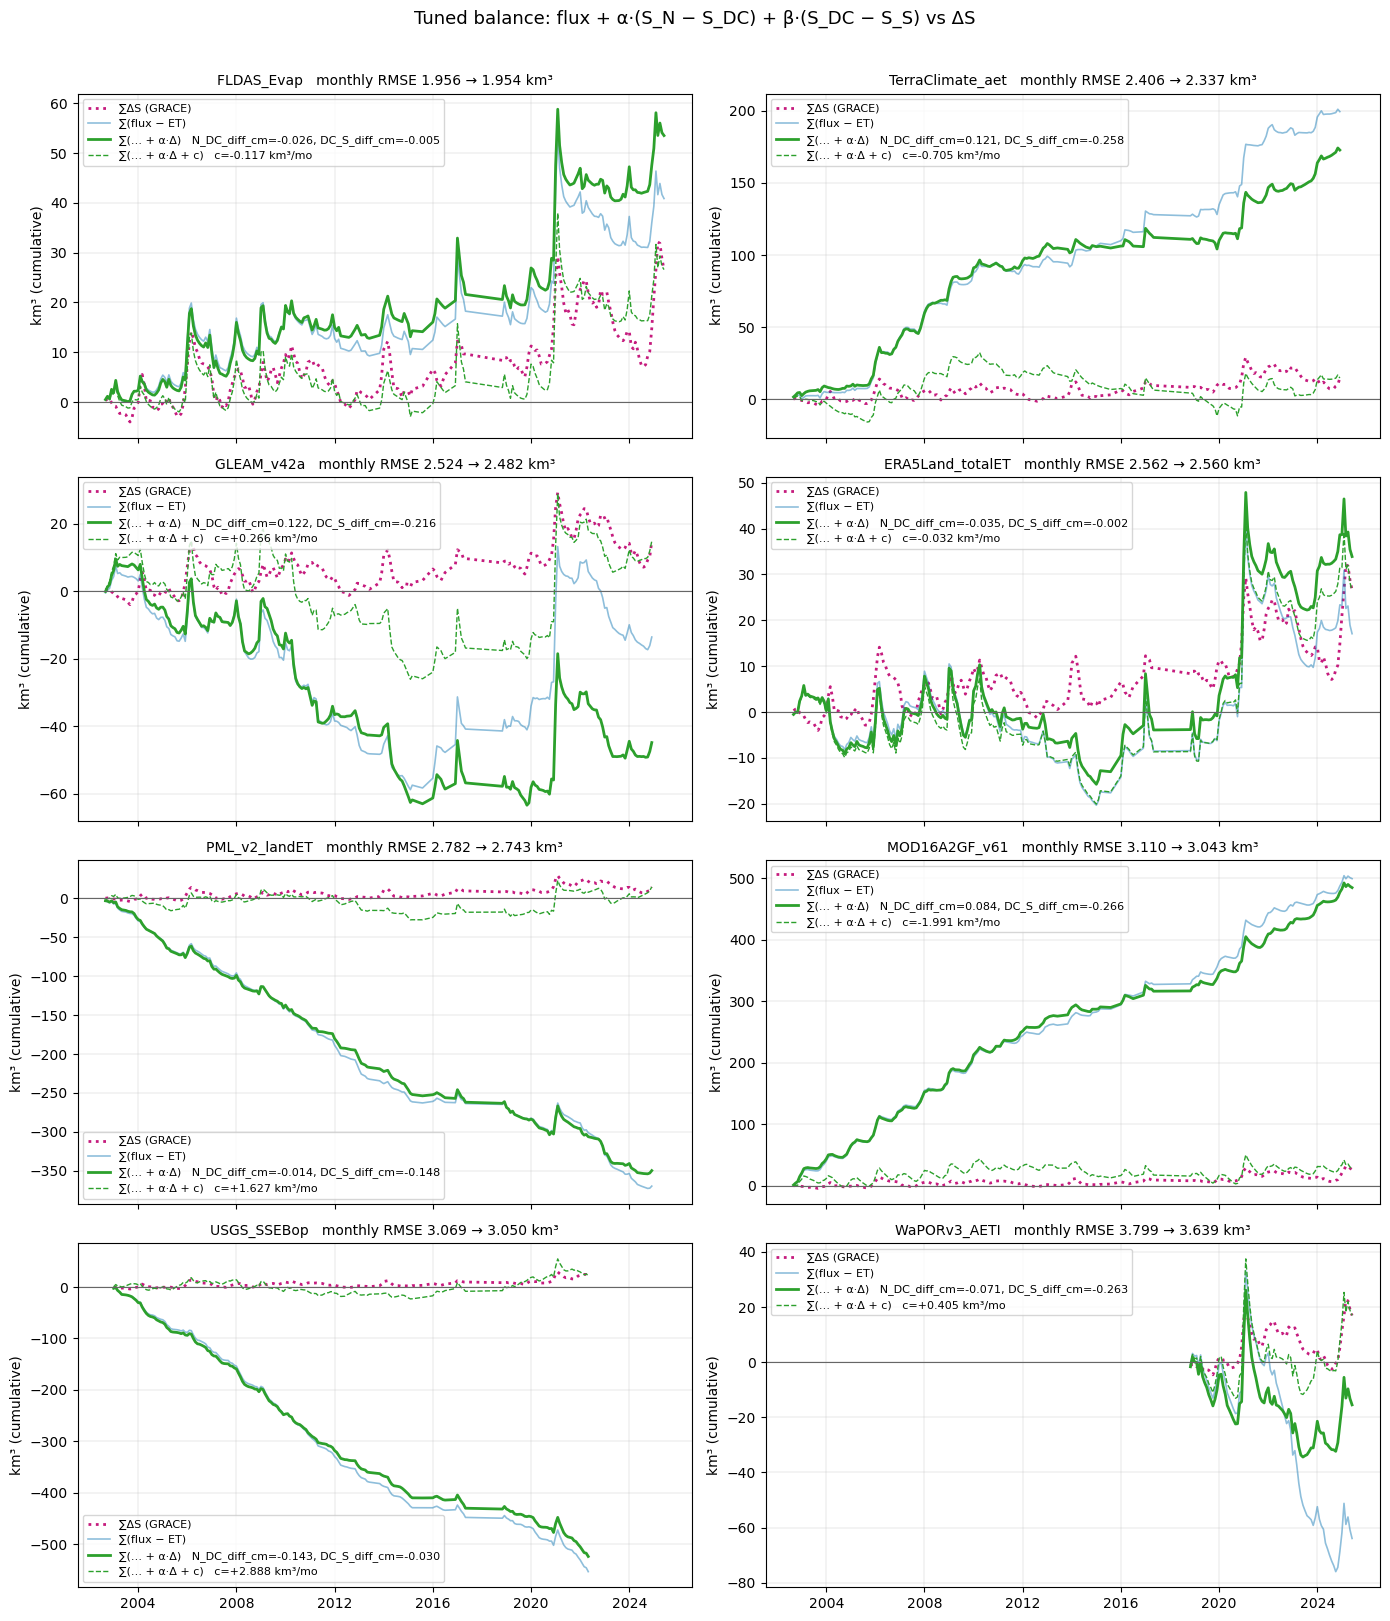

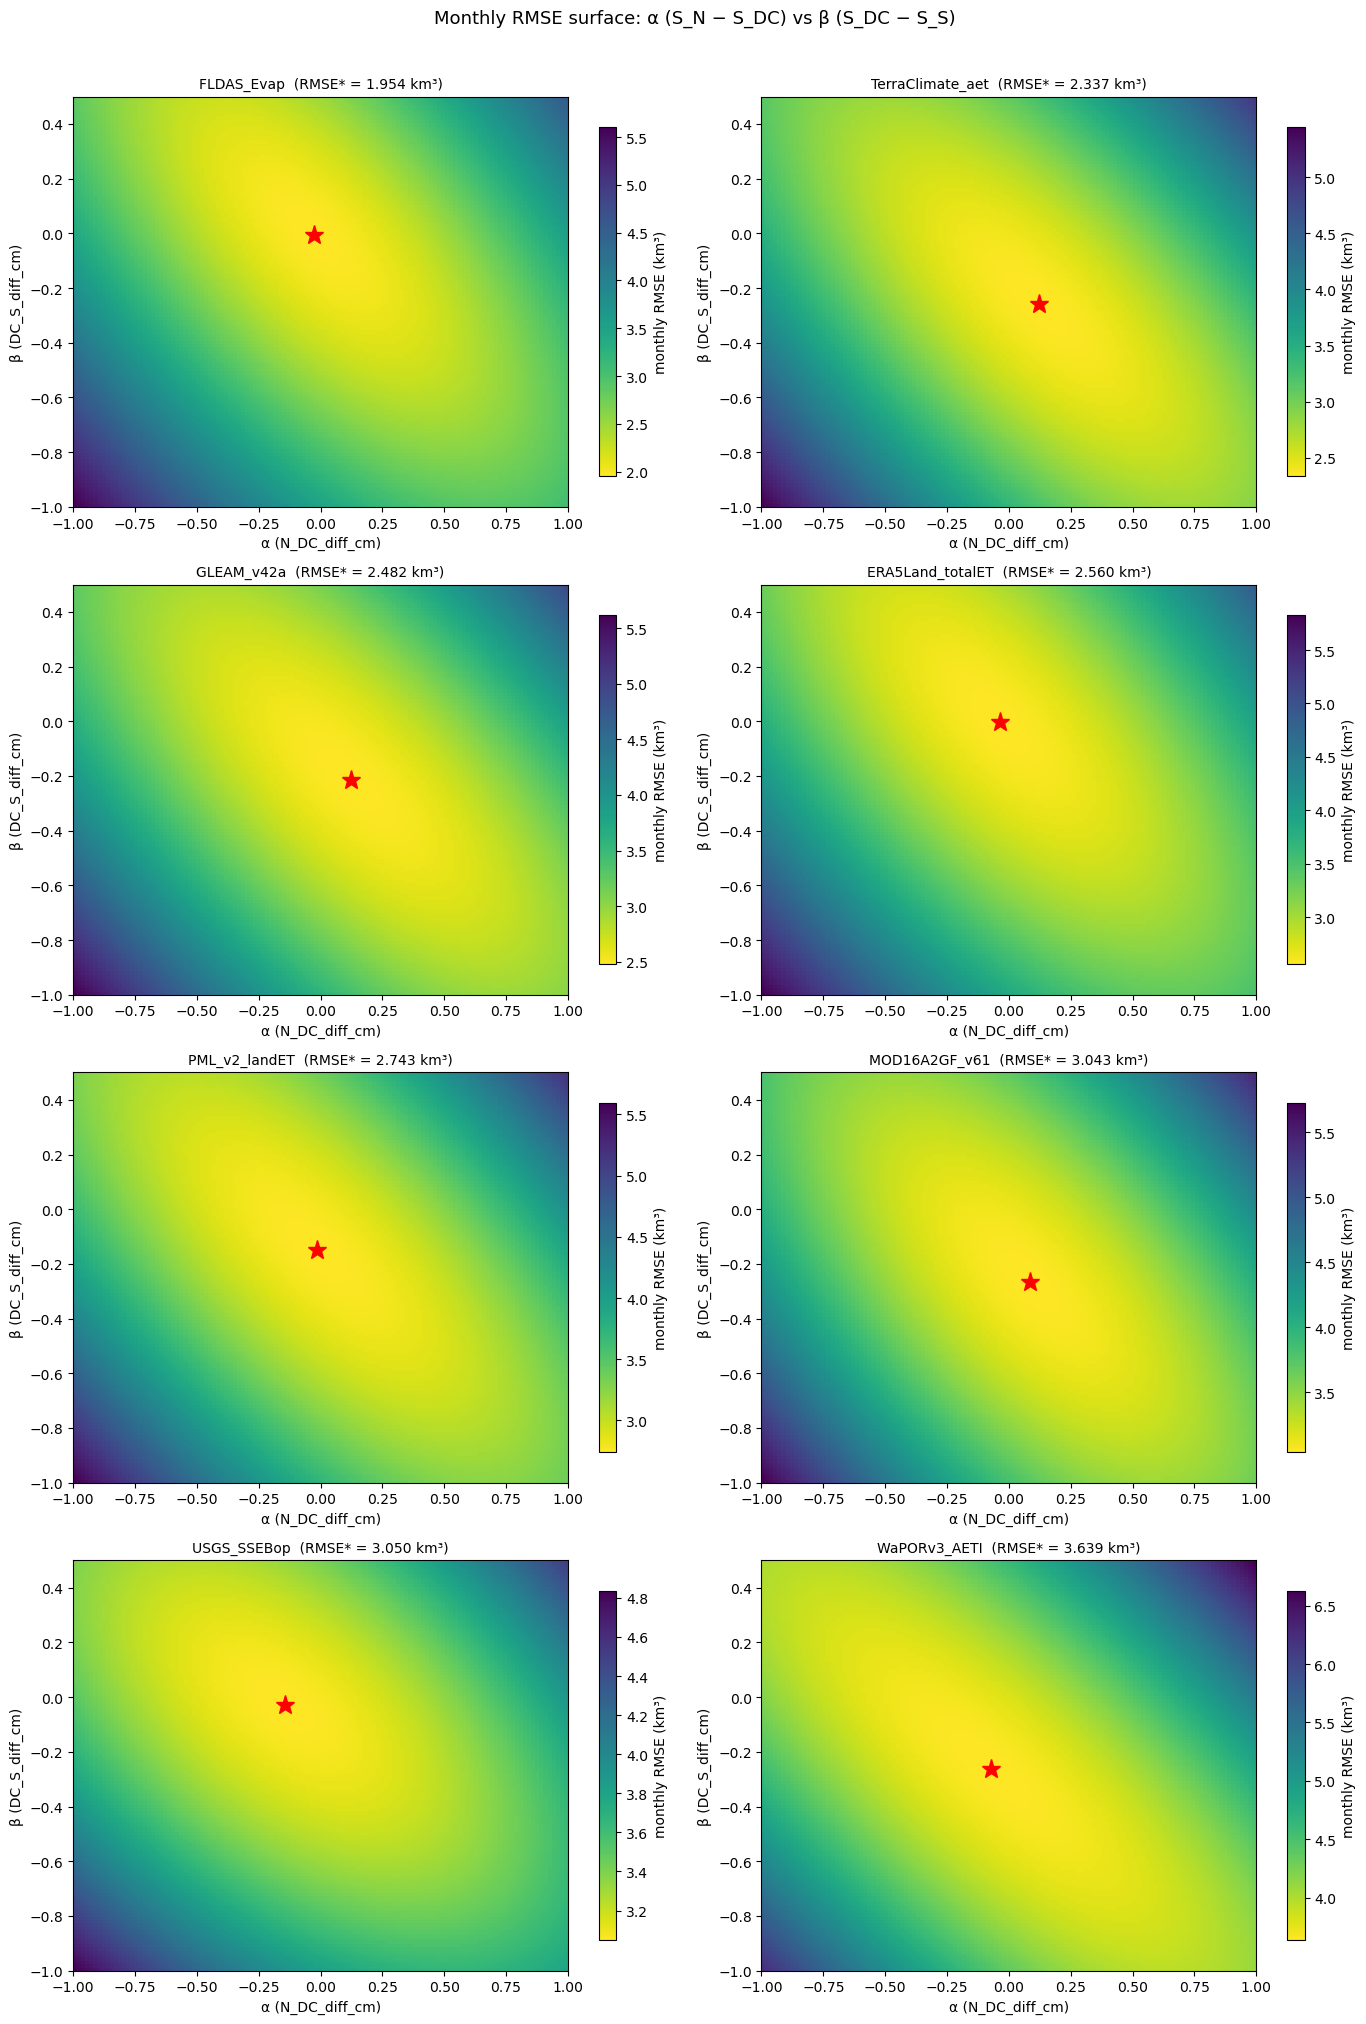

In [15]:
results_2p, plot_2p = per_model_fits(bal, ["N_DC_diff_cm", "DC_S_diff_cm"], bounds=([-np.inf, -np.inf], [np.inf, 0]))
summarize_fits(results_2p, "2-parameter: α × (S_N − S_DC) + β × (S_DC − S_S), β ≤ 0")
bp.plot_tuned_cumulative(results_2p, plot_2p, f"Tuned balance: flux + α·(S_N − S_DC) + β·(S_DC − S_S) vs ΔS",
                         save=FIG_DIR / "tuned_2param_cumulative.png"); plt.show()
bp.plot_rmse_heatmap(bal, results_2p, "N_DC_diff_cm", "DC_S_diff_cm", title=f"Monthly RMSE surface: α (S_N − S_DC) vs β (S_DC − S_S)",
                     save=FIG_DIR / "rmse_2d_heatmap.png"); plt.show()

## 7f — Save outputs

In [16]:
write_outputs(bal, FIG_DIR, GEOM_TAG, USE_BLOCKS, qin=None)
results_1p.to_csv(FIG_DIR / "lateral_flux_1p.csv", index=False)
results_2p.to_csv(FIG_DIR / "lateral_flux_2p.csv", index=False)

Outputs written to /Users/octaviacrompton/Projects/Okavango-water-balance/figures/ET comparison/grace_dry_control


## 8 — Compare with the delta blocks (TWS)

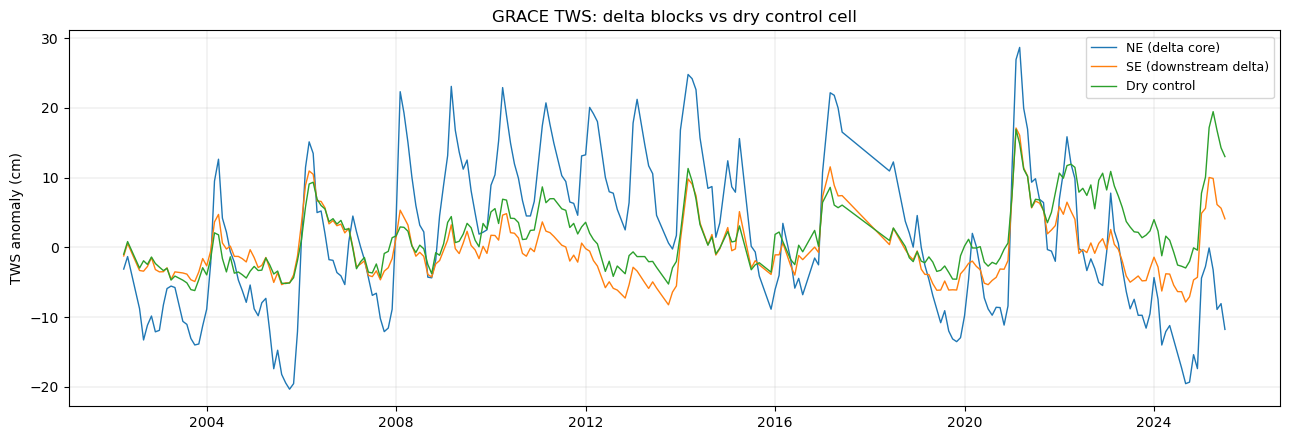

NE (delta core)          std = 10.93 cm
SE (downstream delta)    std = 4.46 cm
Dry control              std = 4.93 cm
Dry control has 45% of the NE block's TWS variability


In [17]:
tws_cmp = {"NE (delta core)": block_tws(GRACE_NC, NE_BLOCK),
           "SE (downstream delta)": block_tws(GRACE_NC, SE_BLOCK),
           "Dry control": block_tws(GRACE_NC, DRY_BLOCK)}
bp.plot_tws_series(tws_cmp, "GRACE TWS: delta blocks vs dry control cell", save=FIG_DIR / "tws_vs_delta_blocks.png")
plt.show()
for k, s in tws_cmp.items():
    print(f"{k:24s} std = {s.std():.2f} cm")
print(f"Dry control has {tws_cmp['Dry control'].std() / tws_cmp['NE (delta core)'].std():.0%} of the NE block's TWS variability")

## 9 — Seasonality

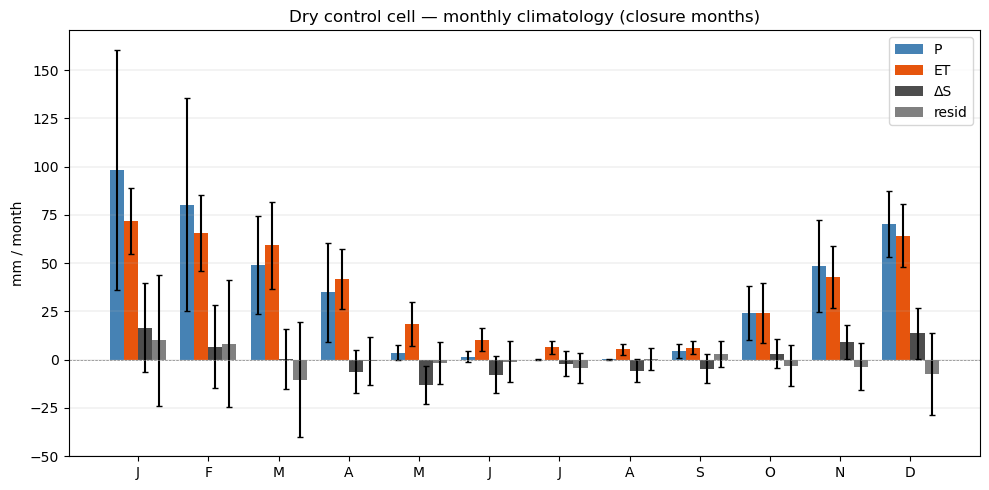

       P_mean  ET_mean  ΔS_mean  resid_mean
month                                      
1        98.4     71.9     16.6        10.0
2        80.4     65.5      6.6         8.2
3        49.2     59.2      0.4       -10.3
4        34.9     41.8     -6.2        -0.8
5         3.6     18.6    -13.1        -1.8
6         1.6     10.4     -7.8        -1.0
7         0.1      6.4     -2.1        -4.2
8         0.1      5.5     -5.7         0.3
9         4.5      6.3     -4.7         3.0
10       24.2     24.2      3.1        -3.1
11       48.6     42.9      9.3        -3.6
12       70.4     64.3     13.6        -7.4


In [18]:
clim = monthly_climatology(bal.closure(), {"P_mm": "P", "ET_mm": "ET", "dS_mm": "ΔS", "resid_mm": "resid"})
bp.plot_climatology(clim, ["P", "ET", "ΔS", "resid"], ["steelblue", "#e6550d", "0.3", "grey"],
                    "Dry control cell — monthly climatology (closure months)", save=FIG_DIR / "climatology.png")
plt.show()
print(clim[[c for c in clim.columns if c.endswith("_mean")]].round(1).to_string())

## 10 — Summary

In [19]:
d = bal.closure()
print("═" * 60); print("DRY CONTROL CELL SUMMARY"); print("═" * 60)
print(f"Block: {describe(DRY_BLOCK)}   area {block_area_m2_/1e6:,.0f} km²")
print(f"Closure months: {len(d)} of {len(bal.df)}")
print("Mean annual fluxes (closure months):")
for c, lab in [("P_mm", "P"), ("ET_mm", "ET"), ("dS_mm", "ΔS"), ("resid_mm", "P − ET − ΔS")]:
    print(f"  {lab:12s} {d[c].mean() * 12:+7.0f} mm/yr")
print(f"P/ET = {d['P_mm'].mean() / d['ET_mm'].mean():.2f}  (≈ 1 expected for a closed dry cell)")

════════════════════════════════════════════════════════════
DRY CONTROL CELL SUMMARY
════════════════════════════════════════════════════════════
Block: B033 (SE)  lon 23.00–26.50  lat -25.50–-22.50  42 px   area 118,339 km²
Closure months: 241 of 294
Mean annual fluxes (closure months):
  P               +440 mm/yr
  ET              +437 mm/yr
  ΔS               +13 mm/yr
  P − ET − ΔS      -10 mm/yr
P/ET = 1.01  (≈ 1 expected for a closed dry cell)
